#### *EDA*

Columns

**id** - globally-unique time step identifier across an entire file

**breath_id** - globally-unique time step for breaths

**R** - lung attribute indicating how restricted the airway is (in cmH2O/L/S). Physically, this is the change in pressure per change in flow (air volume per time). Intuitively, one can imagine blowing up a balloon through a straw. We can change R by changing the diameter of the straw, with higher R being harder to blow.

**C** - lung attribute indicating how compliant the lung is (in mL/cmH2O). Physically, this is the change in volume per change in pressure. Intuitively, one can imagine the same balloon example. We can change C by changing the thickness of the balloon’s latex, with higher C having thinner latex and easier to blow.

**time_step** - the actual time stamp.

**u_in** - the control input for the inspiratory solenoid valve. Ranges from 0 to 100.

**u_out** - the control input for the exploratory solenoid valve. Either 0 or 1.

**pressure** - the airway pressure measured in the respiratory circuit, measured in cmH2O.

In [6]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import kagglehub
from dotenv import load_dotenv

def set_seed(seed: int = 67):
    # random.seed(seed)
    np.random.seed(seed)
set_seed(1488)

In [7]:
load_dotenv() 

path = kagglehub.competition_download('ventilator-pressure-prediction')

print("Path to competition files:", path)

df_train = pd.read_csv(path+"/train.csv")
df_test  = pd.read_csv(path+"/test.csv")

Path to competition files: /root/.cache/kagglehub/competitions/ventilator-pressure-prediction


In [8]:
df_train.info() 
df_train.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06
mean,3.018000e+06,6.283886e+04,2.703618e+01,2.608072e+01,1.307225e+00,7.321615e+00,6.204493e-01,1.122041e+01
std,1.742443e+06,3.633526e+04,1.959549e+01,1.715231e+01,7.659778e-01,1.343470e+01,4.852752e-01,8.109703e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.509001e+06,3.137700e+04,5.000000e+00,1.000000e+01,6.428995e-01,3.936623e-01,0.000000e+00,6.329607e+00
50%,3.018000e+06,6.276550e+04,2.000000e+01,2.000000e+01,1.308123e+00,4.386146e+00,1.000000e+00,7.032628e+00
75%,4.527000e+06,9.430100e+04,5.000000e+01,5.000000e+01,1.965502e+00,4.983895e+00,1.000000e+00,1.364103e+01
max,6.036000e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


In [9]:
df_test.info() 
df_test.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024000 entries, 0 to 4023999
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
dtypes: float64(2), int64(5)
memory usage: 214.9 MB


,id,breath_id,R,C,time_step,u_in,u_out
count,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06,4.024000e+06
mean,2.012000e+06,6.292796e+04,2.710785e+01,2.607038e+01,1.307083e+00,7.338098e+00,6.203864e-01
std,1.161629e+06,3.624924e+04,1.954281e+01,1.717103e+01,7.658902e-01,1.350955e+01,4.852908e-01
min,1.000000e+00,0.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.006001e+06,3.153050e+04,5.000000e+00,1.000000e+01,6.428454e-01,4.096735e-01,0.000000e+00
50%,2.012000e+06,6.305750e+04,2.000000e+01,2.000000e+01,1.308083e+00,4.377512e+00,1.000000e+00
75%,3.018000e+06,9.433325e+04,5.000000e+01,5.000000e+01,1.965240e+00,4.983472e+00,1.000000e+00
max,4.024000e+06,1.257480e+05,5.000000e+01,5.000000e+01,2.935203e+00,1.000000e+02,1.000000e+00


In [10]:
df_train.isnull().sum(), df_test.isnull().sum(), df_train.duplicated().sum(), df_test.duplicated().sum()

(id           0
 breath_id    0
 R            0
 C            0
 time_step    0
 u_in         0
 u_out        0
 pressure     0
 dtype: int64,
 id           0
 breath_id    0
 R            0
 C            0
 time_step    0
 u_in         0
 u_out        0
 dtype: int64,
 np.int64(0),
 np.int64(0))

In [11]:
df_train.nunique().to_frame()

,0
id,6036000
breath_id,75450
R,3
C,3
time_step,3767571
u_in,4020300
u_out,2
pressure,950


<Axes: >

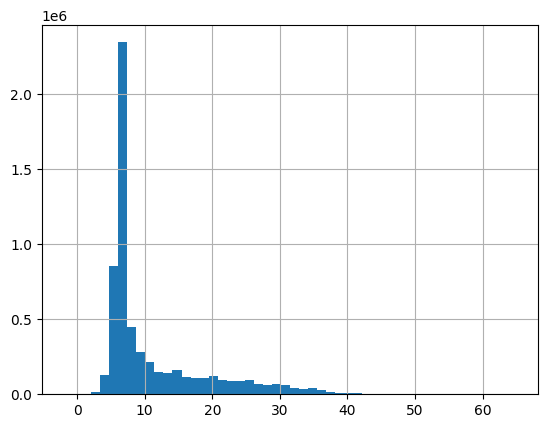

In [12]:
df_train['pressure'].hist(bins=50)

In [13]:
breath_one = df_train[(df_train['breath_id'] == 1)]
breath_one

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987
...,...,...,...,...,...,...,...,...
75,76,1,20,50,2.553593,4.974474,1,6.399909
76,77,1,20,50,2.587754,4.978481,1,6.610815
77,78,1,20,50,2.621773,4.981847,1,6.329607
78,79,1,20,50,2.655746,4.984683,1,6.540513


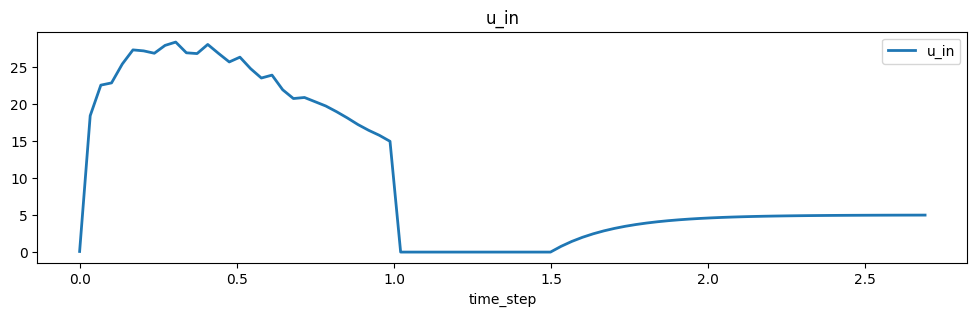

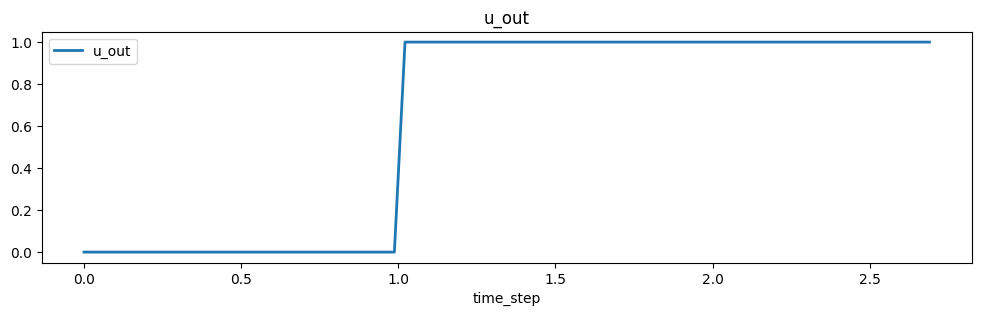

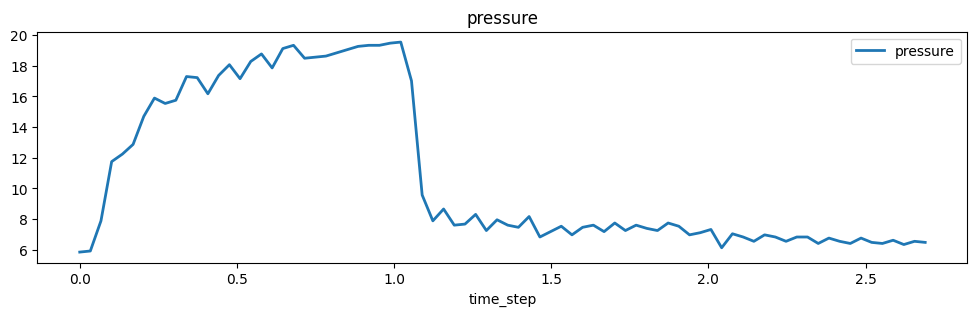

In [14]:
breath_one.plot(x="time_step", y="u_in", kind='line',figsize=(12,3), lw=2, title="u_in");
breath_one.plot(x="time_step", y="u_out", kind='line',figsize=(12,3), lw=2, title="u_out");
breath_one.plot(x="time_step", y="pressure", kind='line',figsize=(12,3), lw=2, title="pressure");

In [15]:
pd.crosstab(df_train["R"],df_train["C"])/60000

C,10,20,50
R,,,
5,11.082667,11.036000,11.028000
20,8.093333,8.277333,10.914667
50,18.236000,11.013333,10.918667


In [16]:
pd.crosstab(df_test["R"],df_test["C"])/40000

C,10,20,50
R,,,
5,10.874,10.902,10.894
20,8.584,8.176,11.000
50,18.162,11.006,11.002


In [17]:
av_model = LogisticRegression()
av_data = pd.concat([df_train.assign(is_test=0),
                     df_test.assign(is_test=1)])

X = av_data.drop(columns=['id', 'breath_id', 'pressure', 'is_test'])
y = av_data['is_test']

av_model.fit(X, y)
y_pred = av_model.predict(X)

In [18]:
print(roc_auc_score(y, y_pred))
print("Happy!")

0.5
Happy!
